In [ ]:
!pip install torch torchvision torchaudio timm wandb torchinfo --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
import numpy as np
import matplotlib.pyplot as plt
import wandb
import random
import os

from sklearn.metrics import confusion_matrix
import seaborn as sns
import io
from PIL import Image

#  1. House Rules: Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# --- 2. WandB Login ---
# Make sure you are logged in
if wandb.run is None:
    wandb.login()

In [ ]:
# --- 3. Data Setup ---
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

def get_dataloaders(aug_strategy="baseline", batch_size=128):
    """
    aug_strategy: 'baseline' (Flip/Crop) or 'randaugment' (Stronger)
    """
    # Base normalization (Always applied)
    base_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    # Training Transforms
    if aug_strategy == "baseline":
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
        ])
    elif aug_strategy == "randaugment":
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            # N=2 ops, M=9 magnitude is standard for CIFAR
            transforms.RandAugment(num_ops=2, magnitude=9),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
        ])

    # Download ONCE
    full_train_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    full_train_clean = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=base_transform)
    test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=base_transform)

    # Split Indices (90/10)
    total_len = len(full_train_aug)
    train_len = int(0.9 * total_len)

    indices = torch.randperm(total_len, generator=torch.Generator().manual_seed(42)).tolist()
    train_idx = indices[:train_len]
    val_idx = indices[train_len:]

    # Create Subsets
    train_dataset = Subset(full_train_aug, train_idx)
    val_dataset = Subset(full_train_clean, val_idx) # Validation is always clean

    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    )




In [ ]:
# --- 4. MixUp Helper Functions ---
def mixup_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:
# 5. The Model (SimpleCNN)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(64 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [ ]:
#  6. Training Engine
def train_one_epoch(model, loader, criterion, optimizer, scaler, scheduler, use_mixup=False):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        # Mixed Precision Context
        with torch.amp.autocast('cuda'):
            # Apply MixUp only if enabled and coin flip is heads (optional, or apply 100%)
            # Here we apply it 100% if enabled for consistency in ablation
            if use_mixup:
                inputs, targets_a, targets_b, lam = mixup_data(inputs, targets)
                outputs = model(inputs)
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()

        # Accuracy (Approximate for MixUp)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

In [ ]:
# --- Helper: Get all predictions for Confusion Matrix ---
def get_all_preds(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return np.array(all_preds), np.array(all_targets)

# --- Helper: Plot Confusion Matrix ---
def plot_confusion_matrix(preds, targets, class_names):
    cm = confusion_matrix(targets, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    return fig





In [ ]:
# --- Updated Experiment Runner ---
def run_experiment(exp_name, aug_strategy, use_mixup=False, epochs=50):

    # 1. Init WandB
    wandb.init(project="Week-3", name=exp_name, reinit=True, config={
        "aug": aug_strategy,
        "mixup": use_mixup,
        "model": "SimpleCNN",
        "epochs": epochs
    })

    print(f"\n STARTING: {exp_name}")

    # 2. Setup
    train_loader, val_loader, test_loader = get_dataloaders(aug_strategy=aug_strategy)
    model = SimpleCNN().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.005, steps_per_epoch=len(train_loader), epochs=epochs
    )
    scaler = torch.amp.GradScaler('cuda')

    best_acc = 0.0

    # 3. Training Loop
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, scheduler, use_mixup
        )
        val_acc = evaluate(model, val_loader, criterion)

        # Log Metrics (Curves)
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "lr": scheduler.get_last_lr()[0]
        })

        print(f"   Epoch {epoch+1}: Train Loss {train_loss:.3f} | Val Acc {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            # Save locally
            torch.save(model.state_dict(), f"{exp_name}_best.pth")

    # 4. End of Training Analysis (Confusion Matrix)
    print("   Generating Confusion Matrix...")
    preds, targets = get_all_preds(model, val_loader)
    class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # Plot and Log Confusion Matrix to WandB
    fig_cm = plot_confusion_matrix(preds, targets, class_names)
    wandb.log({"confusion_matrix": wandb.Image(fig_cm)})
    plt.show() # Show in Notebook too

    # Log the best model artifact to WandB
    artifact = wandb.Artifact(f'model-{exp_name}', type='model')
    artifact.add_file(f"{exp_name}_best.pth")
    wandb.log_artifact(artifact)

    wandb.finish()
    return best_acc





 STARTING: 1_Baseline
   Epoch 1: Train Loss 1.667 | Val Acc 49.72%
   Epoch 2: Train Loss 1.343 | Val Acc 58.54%
   Epoch 3: Train Loss 1.193 | Val Acc 60.42%
   Epoch 4: Train Loss 1.100 | Val Acc 66.38%
   Epoch 5: Train Loss 1.044 | Val Acc 69.10%
   Epoch 6: Train Loss 1.007 | Val Acc 66.74%
   Epoch 7: Train Loss 0.970 | Val Acc 67.22%
   Epoch 8: Train Loss 0.930 | Val Acc 70.76%
   Epoch 9: Train Loss 0.876 | Val Acc 70.32%
   Epoch 10: Train Loss 0.828 | Val Acc 72.94%
   Epoch 11: Train Loss 0.804 | Val Acc 74.54%
   Epoch 12: Train Loss 0.785 | Val Acc 70.50%
   Epoch 13: Train Loss 0.756 | Val Acc 72.98%
   Epoch 14: Train Loss 0.743 | Val Acc 75.28%
   Epoch 15: Train Loss 0.724 | Val Acc 73.32%
   Epoch 16: Train Loss 0.711 | Val Acc 77.82%
   Epoch 17: Train Loss 0.694 | Val Acc 78.24%
   Epoch 18: Train Loss 0.680 | Val Acc 77.72%
   Epoch 19: Train Loss 0.668 | Val Acc 80.14%
   Epoch 20: Train Loss 0.653 | Val Acc 78.68%
   Epoch 21: Train Loss 0.637 | Val Acc 77.56%

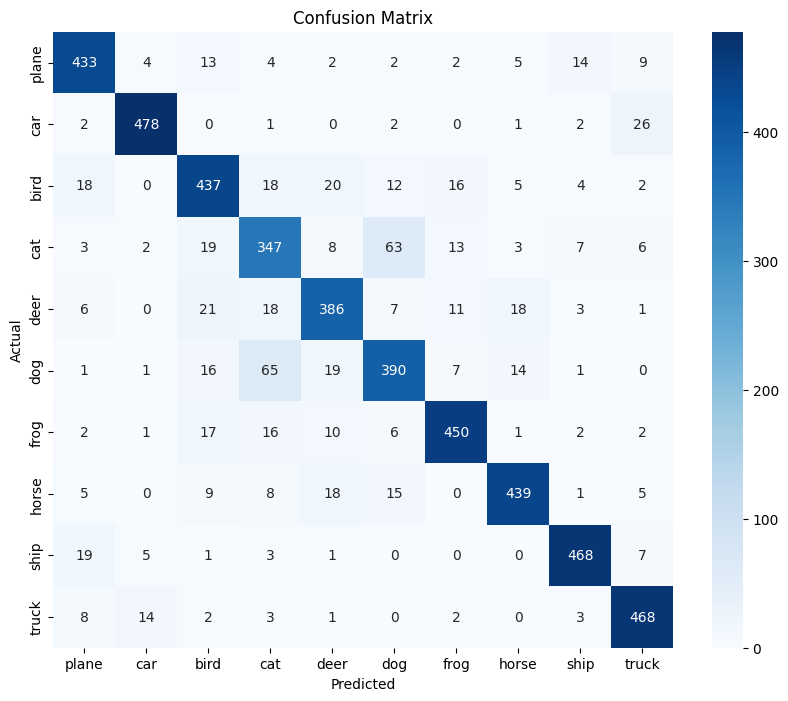

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▂▂▂▃▅▆▆▇▇██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▅▄▅▅▆▅▆▆▆▇▆▇▆▇▇▇▇▇▇▇▇█▇██▇██████████
epoch,50
lr,0.0
train_acc,87.51778
train_loss,0.35982
val_acc,85.92



 STARTING: 2_RandAug
   Epoch 1: Train Loss 1.842 | Val Acc 49.62%
   Epoch 2: Train Loss 1.542 | Val Acc 55.78%
   Epoch 3: Train Loss 1.405 | Val Acc 60.00%
   Epoch 4: Train Loss 1.318 | Val Acc 61.58%
   Epoch 5: Train Loss 1.261 | Val Acc 61.64%
   Epoch 6: Train Loss 1.226 | Val Acc 62.58%
   Epoch 7: Train Loss 1.190 | Val Acc 68.46%
   Epoch 8: Train Loss 1.143 | Val Acc 67.88%
   Epoch 9: Train Loss 1.097 | Val Acc 67.52%
   Epoch 10: Train Loss 1.052 | Val Acc 71.16%
   Epoch 11: Train Loss 1.023 | Val Acc 70.72%
   Epoch 12: Train Loss 0.993 | Val Acc 72.58%
   Epoch 13: Train Loss 0.986 | Val Acc 72.08%
   Epoch 14: Train Loss 0.969 | Val Acc 73.58%
   Epoch 15: Train Loss 0.948 | Val Acc 75.24%
   Epoch 16: Train Loss 0.929 | Val Acc 74.70%
   Epoch 17: Train Loss 0.922 | Val Acc 74.24%
   Epoch 18: Train Loss 0.898 | Val Acc 74.62%
   Epoch 19: Train Loss 0.892 | Val Acc 75.92%
   Epoch 20: Train Loss 0.877 | Val Acc 75.88%
   Epoch 21: Train Loss 0.864 | Val Acc 74.36%


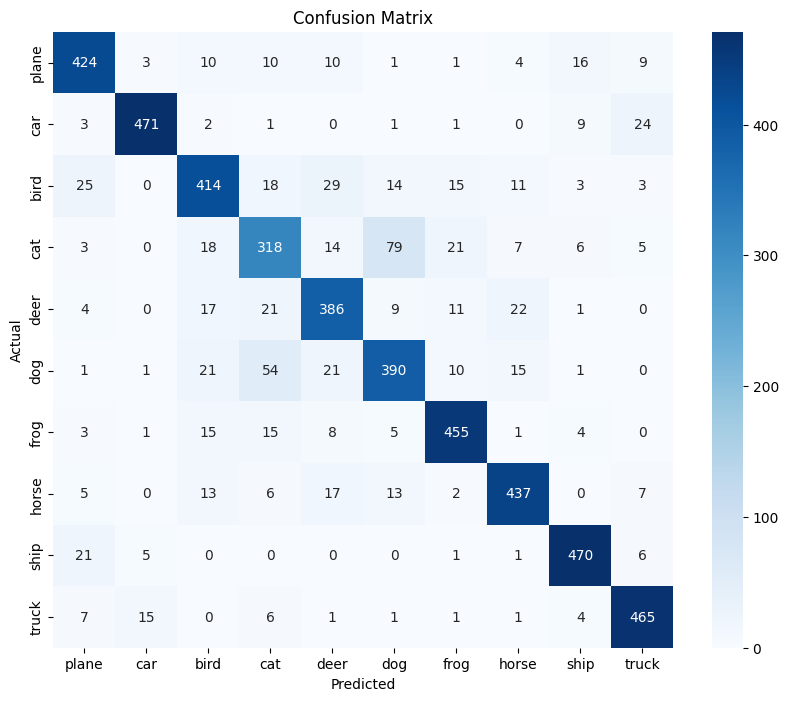

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▂▂▂▃▄▅▆▆▇████████▇▇▇▆▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▆▆▅▅▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▃▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██▇▇██████████
epoch,50
lr,0.0
train_acc,79.80222
train_loss,0.58969
val_acc,84.6



 STARTING: 3_MixUp
   Epoch 1: Train Loss 1.946 | Val Acc 47.86%
   Epoch 2: Train Loss 1.761 | Val Acc 54.18%
   Epoch 3: Train Loss 1.701 | Val Acc 55.34%
   Epoch 4: Train Loss 1.693 | Val Acc 62.34%
   Epoch 5: Train Loss 1.648 | Val Acc 62.08%
   Epoch 6: Train Loss 1.634 | Val Acc 61.18%
   Epoch 7: Train Loss 1.631 | Val Acc 69.56%
   Epoch 8: Train Loss 1.584 | Val Acc 67.12%
   Epoch 9: Train Loss 1.574 | Val Acc 69.02%
   Epoch 10: Train Loss 1.562 | Val Acc 68.46%
   Epoch 11: Train Loss 1.506 | Val Acc 71.08%
   Epoch 12: Train Loss 1.495 | Val Acc 70.68%
   Epoch 13: Train Loss 1.489 | Val Acc 73.18%
   Epoch 14: Train Loss 1.498 | Val Acc 73.60%
   Epoch 15: Train Loss 1.465 | Val Acc 73.68%
   Epoch 16: Train Loss 1.431 | Val Acc 71.26%
   Epoch 17: Train Loss 1.478 | Val Acc 73.14%
   Epoch 18: Train Loss 1.441 | Val Acc 75.70%
   Epoch 19: Train Loss 1.454 | Val Acc 75.22%
   Epoch 20: Train Loss 1.413 | Val Acc 76.08%
   Epoch 21: Train Loss 1.443 | Val Acc 77.46%
  

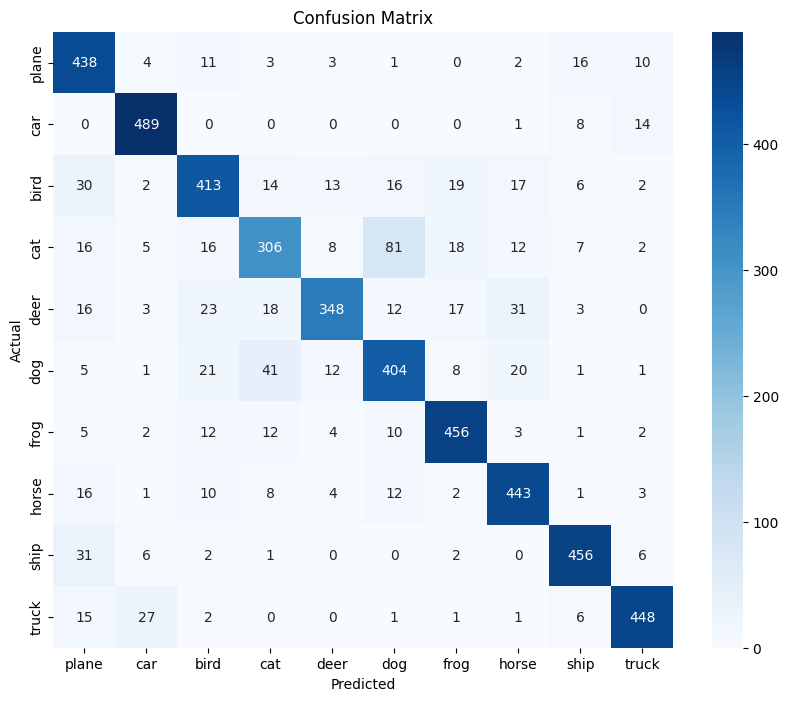

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▂▂▂▃▄▅▆▆▇████████▇▇▆▆▆▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▅▅▇▆▅▆▆▆▇▆▅▆▆▇▇▆▇▇▆▇▇▆▆▇▇▇▇▇▇█▇▇
train_loss,█▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
epoch,50
lr,0.0
train_acc,45.47333
train_loss,1.23915
val_acc,84.02



 STARTING: 4_Combined
   Epoch 1: Train Loss 2.079 | Val Acc 47.50%
   Epoch 2: Train Loss 1.926 | Val Acc 52.96%
   Epoch 3: Train Loss 1.846 | Val Acc 55.64%
   Epoch 4: Train Loss 1.818 | Val Acc 59.80%
   Epoch 5: Train Loss 1.782 | Val Acc 60.72%
   Epoch 6: Train Loss 1.782 | Val Acc 65.48%
   Epoch 7: Train Loss 1.780 | Val Acc 65.90%
   Epoch 8: Train Loss 1.737 | Val Acc 68.64%
   Epoch 9: Train Loss 1.693 | Val Acc 66.68%
   Epoch 10: Train Loss 1.656 | Val Acc 65.80%
   Epoch 11: Train Loss 1.632 | Val Acc 65.98%
   Epoch 12: Train Loss 1.631 | Val Acc 69.36%
   Epoch 13: Train Loss 1.612 | Val Acc 70.20%
   Epoch 14: Train Loss 1.621 | Val Acc 69.92%
   Epoch 15: Train Loss 1.594 | Val Acc 73.20%
   Epoch 16: Train Loss 1.572 | Val Acc 72.20%
   Epoch 17: Train Loss 1.596 | Val Acc 72.46%
   Epoch 18: Train Loss 1.581 | Val Acc 75.34%
   Epoch 19: Train Loss 1.548 | Val Acc 72.36%
   Epoch 20: Train Loss 1.577 | Val Acc 74.18%
   Epoch 21: Train Loss 1.580 | Val Acc 73.26%

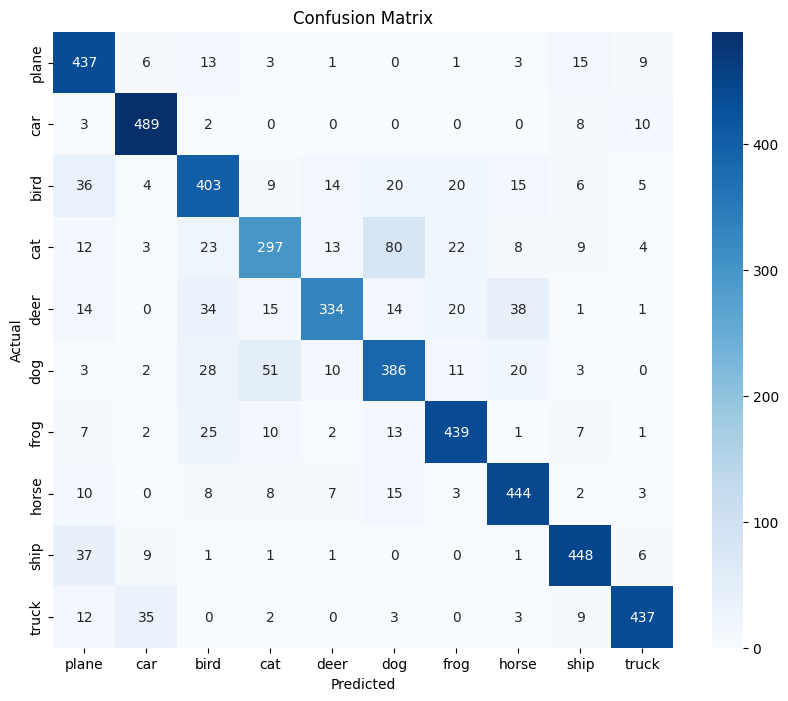

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,▁▂▂▂▃▄▅▆▆▇███████▇▇▇▆▆▆▆▅▅▄▄▄▃▃▂▂▂▂▁▁▁▁▁
train_acc,▁▃▃▄▄▄▅▅▅▅▆▅▆▅▆▆▆▆▇▇▆▇▆▇▇▇▇█▇▇▆▇██████▇█
train_loss,█▆▆▅▅▅▅▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▅▅▅▅▅▅▆▆▆▇▆▆▇▆▇▆▇▇▇▇▇▇██▇███████████
epoch,50
lr,0.0
train_acc,43.22
train_loss,1.38748
val_acc,82.28


In [ ]:
# EXECUTION (50 Epochs)
NUM_EPOCHS = 50

results = {}

# Run the 4 experiments
results['Baseline'] = run_experiment("1_Baseline", aug_strategy="baseline", use_mixup=False, epochs=NUM_EPOCHS)
results['RandAug'] = run_experiment("2_RandAug", aug_strategy="randaugment", use_mixup=False, epochs=NUM_EPOCHS)
results['MixUp'] = run_experiment("3_MixUp", aug_strategy="baseline", use_mixup=True, epochs=NUM_EPOCHS)
results['Combined'] = run_experiment("4_Combined", aug_strategy="randaugment", use_mixup=True, epochs=NUM_EPOCHS)



 Generating Final Summary for WandB 


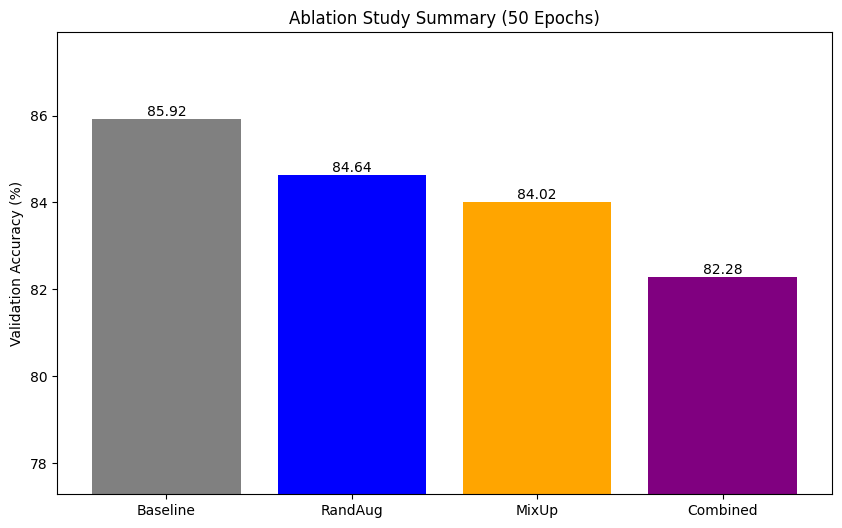

 All runs and summary logged to Weights & Biases!


In [ ]:
# FINAL SUMMARY LOGGING
print("\n Generating Final Summary for WandB ")

# 1. Start a dedicated "Summary" run
wandb.init(project="Week-3", name="Global_Summary", reinit=True)

# 2. Create the Figure
fig_summary, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results.keys(), results.values(), color=['gray', 'blue', 'orange', 'purple'])

# Styling
ax.set_ylim(min(results.values())-5, max(results.values())+2)
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title(f"Ablation Study Summary ({NUM_EPOCHS} Epochs)")
ax.bar_label(bars, fmt='%.2f')

# 3. Log the Figure to WandB
wandb.log({"Ablation_Chart": wandb.Image(fig_summary)})

# 4. Log the Raw Data as a Table (Easier to read in dashboard)
# Convert dictionary to list of lists [[ExpName, Acc], ...]
table_data = [[k, v] for k, v in results.items()]
table = wandb.Table(data=table_data, columns=["Experiment", "Accuracy"])
wandb.log({"Ablation_Results_Table": table})

# 5. Finish
wandb.finish()

# Show locally
plt.show()
print(" All runs and summary logged to Weights & Biases!")

Starting Evaluation on TEST SET (Using saved .pth files)...
Loading Baseline from 1_Baseline_best.pth...
Baseline Test Acc: 85.50%
Loading RandAug from 2_RandAug_best.pth...
RandAug Test Acc: 84.09%
Loading MixUp from 3_MixUp_best.pth...
MixUp Test Acc: 83.47%
Loading Combined from 4_Combined_best.pth...
Combined Test Acc: 82.54%

Uploading Final Test Summary to WandB


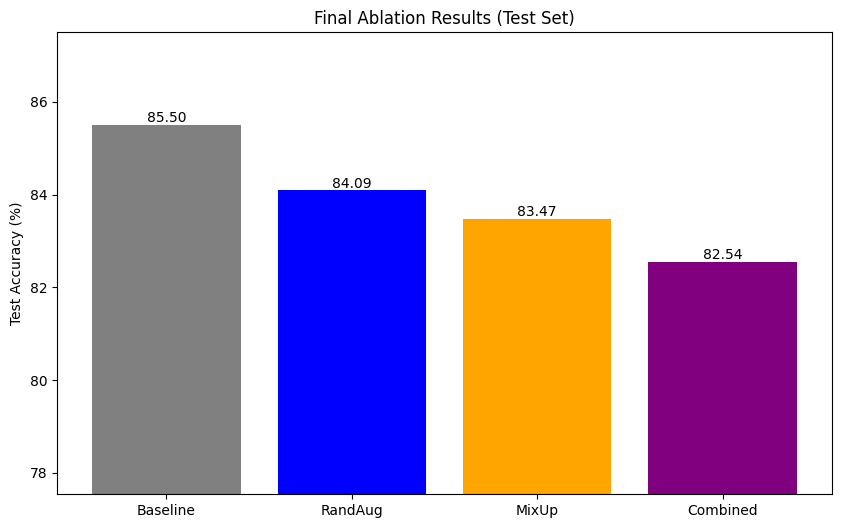

 Successfully logged the Test Accuracy.


In [ ]:
#POST-TRAINING TEST EVALUATION

print("Starting Evaluation on TEST SET (Using saved .pth files)...")

# 1. Setup Test Loader (Standard clean transform)
# We can use 'baseline' strategy here because get_dataloaders
# returns the same clean test_loader regardless of training strategy.
_, _, test_loader = get_dataloaders(aug_strategy="baseline")

# 2. Define the files we expect to find
# These names must match what you used in 'run_experiment' earlier
model_files = {
    "Baseline": "1_Baseline_best.pth",
    "RandAug":  "2_RandAug_best.pth",
    "MixUp":    "3_MixUp_best.pth",
    "Combined": "4_Combined_best.pth"
}

test_results = {}
criterion = nn.CrossEntropyLoss()

# 3. Loop through saved files and evaluate
for name, file_path in model_files.items():
    if not os.path.exists(file_path):
        print(f"Warning: Could not find {file_path}. Skipping.")
        continue

    print(f"Loading {name} from {file_path}...")

    # Re-initialize a fresh model
    model = SimpleCNN().to(device)

    # Load weights
    # map_location ensures it loads to GPU if available, or CPU if not
    model.load_state_dict(torch.load(file_path, map_location=device))

    # Evaluate
    test_acc = evaluate(model, test_loader, criterion)
    test_results[name] = test_acc

    print(f"{name} Test Acc: {test_acc:.2f}%")

#LOG FINAL TEST RESULTS TO WANDB


print("\nUploading Final Test Summary to WandB")

# Start a specific "Summary" run
wandb.init(project="Week-3", name="Final_Test_Evaluation", reinit=True)

# 1. Create Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(test_results.keys(), test_results.values(), color=['gray', 'blue', 'orange', 'purple'])

# Dynamic Y-Axis limits to show differences clearly
min_val = min(test_results.values())
max_val = max(test_results.values())
ax.set_ylim(min_val - 5, max_val + 2)

ax.set_ylabel("Test Accuracy (%)")
ax.set_title(f"Final Ablation Results (Test Set)")
ax.bar_label(bars, fmt='%.2f')

# 2. Log Image
wandb.log({"Test_Accuracy_Chart": wandb.Image(fig)})

# 3. Log Table
table_data = [[k, v] for k, v in test_results.items()]
table = wandb.Table(data=table_data, columns=["Model Variant", "Test Accuracy"])
wandb.log({"Test_Results_Table": table})

wandb.finish()

plt.show()
print(" Successfully logged the Test Accuracy.")

In [ ]:
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
# It will ask for permission. Click "Connect to Google Drive".
drive.mount('/content/drive')

# 2. Define a Permanent Path
# This creates a folder in your Drive called "Week3_Vision"
PROJECT_DIR = "/content/drive/MyDrive/Week3_Vision"
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Created permanent storage at: {MODELS_DIR}")

# 3. Rescue the .pth files
# These are the files currently sitting in the temporary Colab storage
files_to_save = [
    "1_Baseline_best.pth",
    "2_RandAug_best.pth",
    "3_MixUp_best.pth",
    "4_Combined_best.pth"
]

print("\n Backing up files to Google Drive...")

for filename in files_to_save:
    source = f"/content/{filename}"
    destination = os.path.join(MODELS_DIR, filename)

    if os.path.exists(source):
        shutil.copy(source, destination)
        print(f"Saved: {filename} -> {destination}")
    else:
        print(f"Warning: Could not find {filename} in current session.")

print("\Models are saved in Google Drive.")

<>:38: SyntaxWarning: invalid escape sequence '\M'
<>:38: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipython-input-3172510619.py:38: SyntaxWarning: invalid escape sequence '\M'
  print("\Models are saved in Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created permanent storage at: /content/drive/MyDrive/Week3_Vision/models

 Backing up files to Google Drive...
Saved: 1_Baseline_best.pth -> /content/drive/MyDrive/Week3_Vision/models/1_Baseline_best.pth
Saved: 2_RandAug_best.pth -> /content/drive/MyDrive/Week3_Vision/models/2_RandAug_best.pth
Saved: 3_MixUp_best.pth -> /content/drive/MyDrive/Week3_Vision/models/3_MixUp_best.pth
Saved: 4_Combined_best.pth -> /content/drive/MyDrive/Week3_Vision/models/4_Combined_best.pth
\Models are saved in Google Drive.


In [ ]:
# Booster Battle---> Cutout vs MixUp vs CutMix ablation

In [ ]:
# !pip install torch torchvision wandb matplotlib seaborn scikit-learn --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import wandb
import random
import os

# ==========================================
# 1. SETUP & REPRODUCIBILITY
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Login to WandB (if not already logged in)
if wandb.run is None:
    wandb.login()

# ==========================================
# 2. DATA & AUGMENTATION LOGIC
# ==========================================
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

def get_booster_loaders(strategy="baseline", batch_size=128):
    """
    strategy: 'baseline' (for MixUp/CutMix) or 'cutout' (adds RandomErasing)
    """
    # Base normalization
    base_ops = [transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)]

    # Standard Augmentations
    aug_ops = [transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip()]

    if strategy == "cutout":
        # Cutout = RandomErasing (Must happen AFTER ToTensor/Normalize)
        final_train_tf = transforms.Compose(aug_ops + base_ops + [
            transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0)
        ])
    else:
        # Baseline (Used for MixUp/CutMix too)
        final_train_tf = transforms.Compose(aug_ops + base_ops)

    test_tf = transforms.Compose(base_ops)

    # Download & Load
    train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=final_train_tf)
    test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    )

# --- MixUp Logic ---
def mixup_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# --- CutMix Logic ---
def cutmix_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    H, W = x.shape[2], x.shape[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, bby1:bby2, bbx1:bbx2] = x[index, :, bby1:bby2, bbx1:bbx2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))

    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

def booster_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)





Using device: cuda


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:

# ==========================================
# 3. MODEL ARCHITECTURE
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Slightly wider model to handle strong augmentations
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [ ]:
# ==========================================
# 4. VISUALIZATION HELPERS
# ==========================================
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.set_title(f"{title}: Loss")
    ax1.set_xlabel("Epoch")
    ax1.grid(True)
    ax1.legend()

    # Accuracy
    ax2.plot(history['val_acc'], color='orange', label='Val Acc')
    ax2.set_title(f"{title}: Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return fig

def generate_cm(model, loader, classes):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    return fig

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total


In [ ]:
# ==========================================
# 5. TRAINING ENGINE
# ==========================================
def train_booster(booster_type, epochs=50):

    # Setup Strategy
    # 'cutout' changes the DataLoader. 'mixup'/'cutmix' change the Loop.
    data_strategy = "cutout" if booster_type == "cutout" else "baseline"
    exp_name = f"Booster_{booster_type}"

    # Init WandB
    wandb.init(project="Week-3", name=exp_name, reinit=True, config={
        "booster": booster_type,
        "epochs": epochs,
        "model": "SimpleCNN"
    })

    print(f"\nSTARTING TRAINING: {booster_type}")
    print(f"   Using Data Strategy: {data_strategy}")

    train_loader, test_loader = get_booster_loaders(data_strategy)
    model = SimpleCNN().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.005, steps_per_epoch=len(train_loader), epochs=epochs)
    scaler = torch.amp.GradScaler('cuda')

    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                # === BOOSTER APPLICATION ===
                if booster_type == "mixup":
                    inputs, targets_a, targets_b, lam = mixup_data(inputs, targets)
                    outputs = model(inputs)
                    loss = booster_criterion(criterion, outputs, targets_a, targets_b, lam)
                elif booster_type == "cutmix":
                    inputs, targets_a, targets_b, lam = cutmix_data(inputs, targets)
                    outputs = model(inputs)
                    loss = booster_criterion(criterion, outputs, targets_a, targets_b, lam)
                else:
                    # Standard (or Cutout, which is in DataLoader)
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_loss += loss.item()

        # Evaluation
        val_acc = evaluate(model, test_loader)
        avg_loss = train_loss/len(train_loader)

        # Logging & History
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        wandb.log({"epoch": epoch+1, "train_loss": avg_loss, "val_acc": val_acc})

        # PRINT PROGRESS (Visible Output)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.3f} | Acc: {val_acc:.2f}%")

        # Save Best
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{exp_name}_best.pth")

    print(f" {booster_type} Complete. Best Acc: {best_acc:.2f}%")

    # --- Post-Training Artifacts ---
    print("  generating plots & logging to WandB...")

    # 1. Curves
    fig_curves = plot_history(history, title=exp_name)
    wandb.log({"Training_Curves": wandb.Image(fig_curves)})

    # 2. Confusion Matrix
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    fig_cm = generate_cm(model, test_loader, classes)
    wandb.log({"Confusion_Matrix": wandb.Image(fig_cm)})

    # 3. Model Artifact
    artifact = wandb.Artifact(f'model-{exp_name}', type='model')
    artifact.add_file(f"{exp_name}_best.pth")
    wandb.log_artifact(artifact)

    wandb.finish()
    return best_acc


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



STARTING TRAINING: cutout
   Using Data Strategy: cutout


100%|██████████| 170M/170M [00:04<00:00, 41.7MB/s]


   Epoch 1/50 | Loss: 1.604 | Acc: 56.81%
   Epoch 5/50 | Loss: 1.127 | Acc: 66.40%
   Epoch 10/50 | Loss: 0.876 | Acc: 76.55%
   Epoch 15/50 | Loss: 0.761 | Acc: 80.50%
   Epoch 20/50 | Loss: 0.687 | Acc: 82.33%
   Epoch 25/50 | Loss: 0.617 | Acc: 83.36%
   Epoch 30/50 | Loss: 0.540 | Acc: 84.65%
   Epoch 35/50 | Loss: 0.464 | Acc: 86.46%
   Epoch 40/50 | Loss: 0.398 | Acc: 87.77%
   Epoch 45/50 | Loss: 0.363 | Acc: 88.66%
   Epoch 50/50 | Loss: 0.346 | Acc: 88.76%
 cutout Complete. Best Acc: 88.76%
  generating plots & logging to WandB...


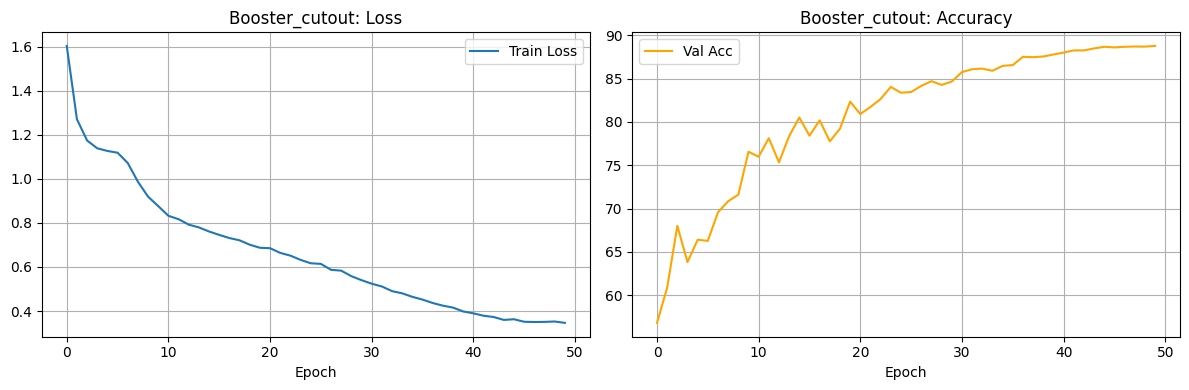

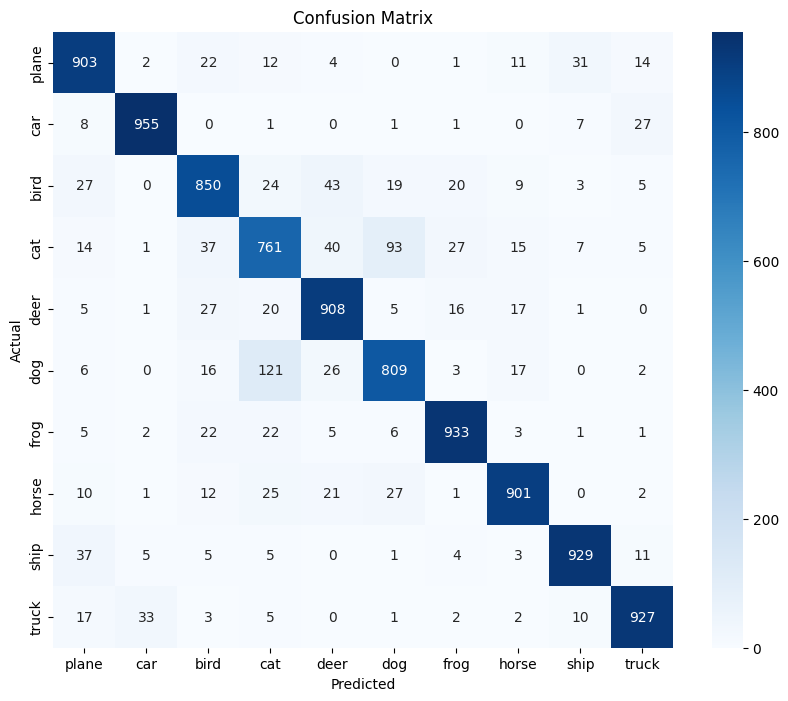

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▆▅▅▅▅▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▃▄▄▄▅▅▅▆▆▆▆▆▇▆▆▇▇▇▇▇▇▇▇▇▇███████████
epoch,50
train_loss,0.3462
val_acc,88.76



STARTING TRAINING: mixup
   Using Data Strategy: baseline
   Epoch 1/50 | Loss: 1.895 | Acc: 54.61%
   Epoch 5/50 | Loss: 1.638 | Acc: 68.80%
   Epoch 10/50 | Loss: 1.470 | Acc: 73.55%
   Epoch 15/50 | Loss: 1.416 | Acc: 75.82%
   Epoch 20/50 | Loss: 1.379 | Acc: 80.75%
   Epoch 25/50 | Loss: 1.320 | Acc: 80.91%
   Epoch 30/50 | Loss: 1.273 | Acc: 83.03%
   Epoch 35/50 | Loss: 1.228 | Acc: 84.95%
   Epoch 40/50 | Loss: 1.217 | Acc: 86.38%
   Epoch 45/50 | Loss: 1.150 | Acc: 86.56%
   Epoch 50/50 | Loss: 1.182 | Acc: 86.11%
 mixup Complete. Best Acc: 86.81%
  generating plots & logging to WandB...


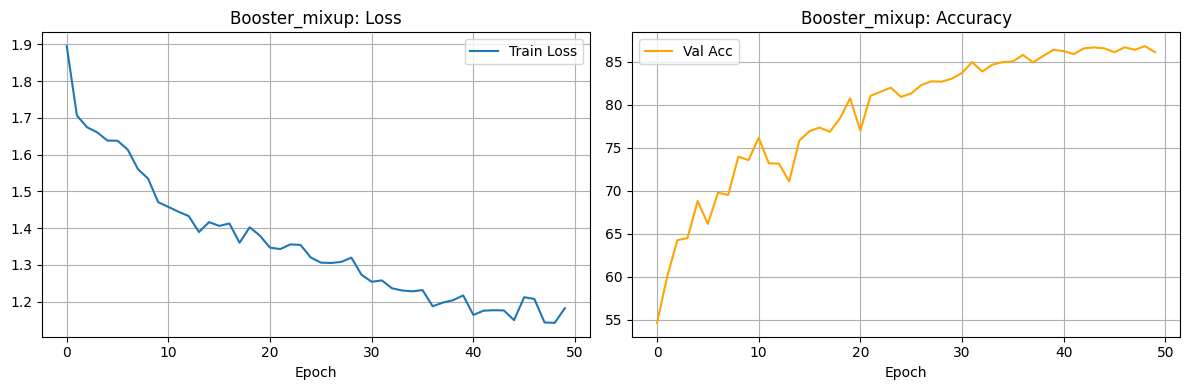

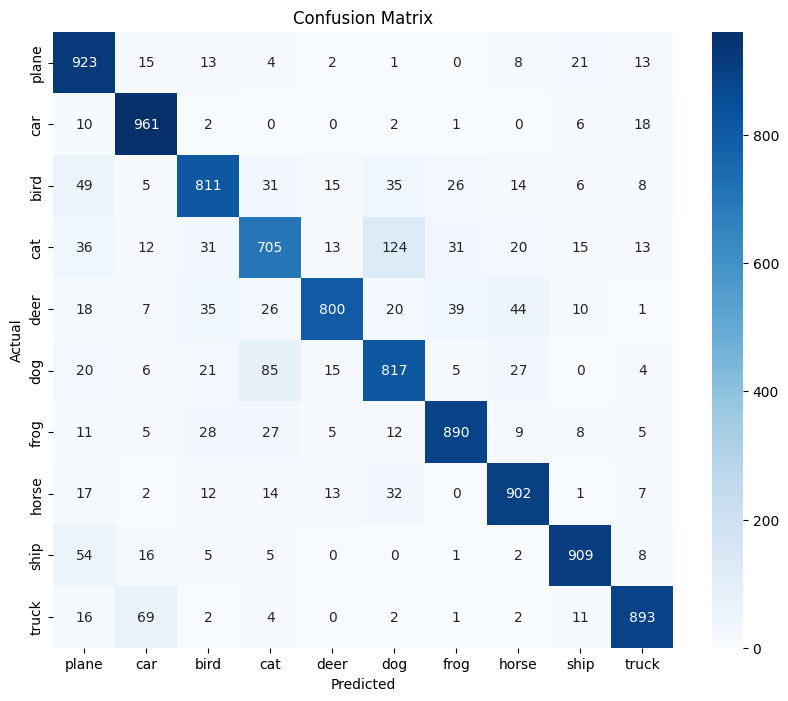

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train_loss,█▆▆▆▆▅▅▅▄▄▄▃▄▃▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▂▂▁▁▁▂▂▁▁
val_acc,▁▂▃▃▄▄▄▅▅▆▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇█▇█████████████
epoch,50
train_loss,1.18222
val_acc,86.11



STARTING TRAINING: cutmix
   Using Data Strategy: baseline
   Epoch 1/50 | Loss: 1.996 | Acc: 51.65%
   Epoch 5/50 | Loss: 1.757 | Acc: 59.14%
   Epoch 10/50 | Loss: 1.586 | Acc: 69.61%
   Epoch 15/50 | Loss: 1.507 | Acc: 76.11%
   Epoch 20/50 | Loss: 1.465 | Acc: 78.37%
   Epoch 25/50 | Loss: 1.393 | Acc: 79.54%
   Epoch 30/50 | Loss: 1.365 | Acc: 82.46%
   Epoch 35/50 | Loss: 1.324 | Acc: 83.51%
   Epoch 40/50 | Loss: 1.289 | Acc: 85.55%
   Epoch 45/50 | Loss: 1.237 | Acc: 86.55%
   Epoch 50/50 | Loss: 1.231 | Acc: 86.76%
 cutmix Complete. Best Acc: 86.79%
  generating plots & logging to WandB...


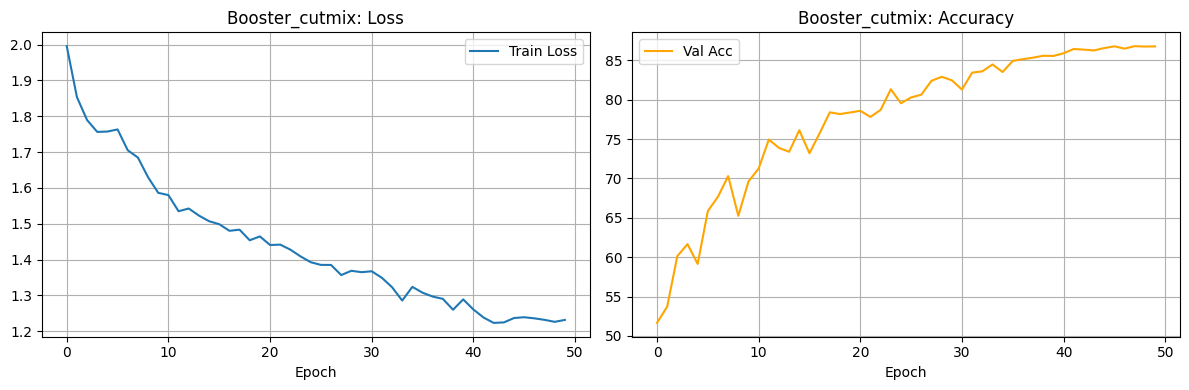

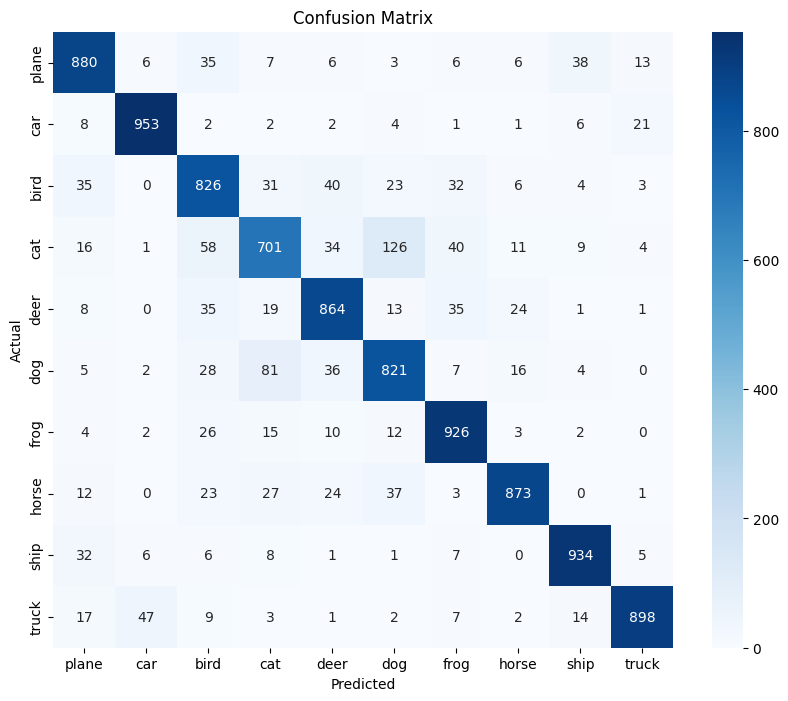

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▇▆▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
val_acc,▁▁▃▃▂▄▄▅▅▆▅▆▅▆▆▆▆▆▆▇▇▇▇▇▇▇█▇████████████
epoch,50
train_loss,1.23149
val_acc,86.76



FINAL RESULTS
Cutout    : 88.76%
MixUp     : 86.81%
CutMix    : 86.79%


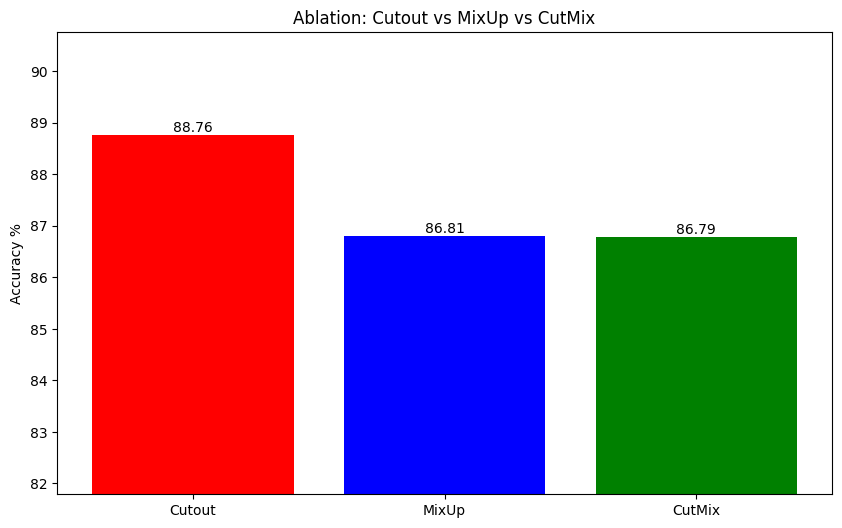

In [ ]:
# ==========================================
# 6. EXECUTION: BATTLE OF BOOSTERS
# ==========================================
results = {}

# 1. Cutout
results['Cutout'] = train_booster("cutout", epochs=50)

# 2. MixUp
results['MixUp'] = train_booster("mixup", epochs=50)

# 3. CutMix
results['CutMix'] = train_booster("cutmix", epochs=50)

# --- Final Comparison Plot ---
print("\nFINAL RESULTS")
for k, v in results.items():
    print(f"{k:<10}: {v:.2f}%")

plt.figure(figsize=(10,6))
bars = plt.bar(results.keys(), results.values(), color=['red', 'blue', 'green'])
plt.ylim(min(results.values())-5, max(results.values())+2)
plt.ylabel("Accuracy %")
plt.title("Ablation: Cutout vs MixUp vs CutMix")
plt.bar_label(bars, fmt='%.2f')
plt.show()

In [ ]:
# import shutil
# import os
# from google.colab import drive

# drive.mount('/content/drive')

# # Target Folder
# DRIVE_DIR = "/content/drive/MyDrive/Week3_Vision/models"
# os.makedirs(DRIVE_DIR, exist_ok=True)

# # Files to move
# files = ["Booster_cutout_best.pth", "Booster_mixup_best.pth", "Booster_cutmix_best.pth"]

# for f in files:
#     if os.path.exists(f):
#         dest = os.path.join(DRIVE_DIR, f)
#         shutil.copy(f, dest)
#         print(f"Saved {f} to Drive")
#     else:
#         print(f" Could not find {f} (Maybe training hasnt finished)")

In [ ]:
# !pip install torch torchvision timm wandb matplotlib seaborn scikit-learn --quiet
# Day-3

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import wandb
import time
import os
import random
from google.colab import drive

# ==========================================
# 1. SETUP & DRIVE
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Mount Drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/Week3_Vision/models"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f" Models will be saved to: {SAVE_DIR}")

if wandb.run is None:
    wandb.login()


Using device: cuda
Mounted at /content/drive
 Models will be saved to: /content/drive/MyDrive/Week3_Vision/models


In [ ]:
# DATA LOADERS (Baseline is sufficient for Transfer)

def get_dataloaders(batch_size=128):
    STATS = ((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(*STATS)
    ])

    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(*STATS)
    ])

    train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
    test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

    # Split Val
    train_size = int(0.9 * len(train_ds))
    val_size = len(train_ds) - train_size
    train_subset, val_subset = torch.utils.data.random_split(train_ds, [train_size, val_size], generator=torch.Generator().manual_seed(42))

    # Val set shouldn't have augs technically, but for Day 3 simplicity in transfer learning,
    # using the split from train_ds is acceptable. Ideally, we load twice (Day 1 method).

    return (
        DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2),
        DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    )


In [ ]:
# MODEL FACTORY (With CIFAR Patch)

def get_resnet18(strategy="freeze"):
    print(f" Building ResNet18 (Strategy: {strategy})")

    # 1. Load Pretrained
    model = timm.create_model('resnet18', pretrained=True, num_classes=10)

    # 2. THE CIFAR PATCH (Fixes resolution mismatch)
    # Replace standard 7x7 stride 2 conv with 3x3 stride 1
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    # Remove the first pooling layer
    model.maxpool = nn.Identity()

    # 3. Handle Freezing
    if strategy == "freeze":
        # Freeze ALL parameters first
        for param in model.parameters():
            param.requires_grad = False
        # Unfreeze ONLY the Head (fc)
        for param in model.fc.parameters():
            param.requires_grad = True
        # Note: Since we replaced conv1, we typically need to unfreeze it too
        # so it learns the new weights, but strictly 'freeze' means backbone is fixed.
        # For CIFAR patch to work best, we usually unfreeze conv1 too.
        for param in model.conv1.parameters():
            param.requires_grad = True

    elif strategy == "unfreeze":
        # Unfreeze EVERYTHING
        for param in model.parameters():
            param.requires_grad = True

    return model.to(device)


In [ ]:
# VISUALIZATION HELPERS

def plot_results(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.set_title(f'{title} Loss')
    ax1.legend()
    ax2.plot(history['val_acc'], color='orange', label='Val Acc')
    ax2.set_title(f'{title} Accuracy')
    ax2.legend()
    plt.show()
    return fig

def generate_cm(model, loader, classes):
    model.eval()
    preds, targets_list = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, p = out.max(1)
            preds.extend(p.cpu().numpy())
            targets_list.extend(y.cpu().numpy())
    cm = confusion_matrix(targets_list, preds)
    fig, ax = plt.subplots(figsize=(8,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    return fig

In [ ]:
# TRAINING ENGINE (With Label Smoothing)

def train_transfer(exp_name, strategy, epochs=15):

    # Setup
    wandb.init(project="Week-3", name=exp_name, reinit=True, config={
        "model": "ResNet18",
        "strategy": strategy,
        "epochs": epochs,
        "label_smoothing": 0.1
    })

    print(f"\n Starting : {exp_name}")

    train_loader, val_loader, test_loader = get_dataloaders()
    model = get_resnet18(strategy)

    # Config
    if strategy == "freeze":
        lr = 1e-3 # Higher LR for head
    else:
        lr = 1e-4 # Lower LR for fine-tuning entire net

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # Label Smoothing added here!
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs)

    # Loop
    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, pred = outputs.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        val_acc = 100 * correct / total
        avg_loss = train_loss / len(train_loader)

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)

        wandb.log({"epoch": epoch+1, "train_loss": avg_loss, "val_acc": val_acc})
        print(f"   Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.3f} | Val Acc: {val_acc:.2f}%")

        # Save Best to Drive
        if val_acc > best_acc:
            best_acc = val_acc
            save_path = os.path.join(SAVE_DIR, f"{exp_name}_best.pth")
            torch.save(model.state_dict(), save_path)

    total_time = time.time() - start_time
    print(f" Finished. Best Acc: {best_acc:.2f}% | Time: {total_time:.1f}s")
    print(f" Saved model to: {save_path}")

    # Final Artifacts
    print(" generating plots..")

    # Curves
    fig_curves = plot_results(history, exp_name)
    wandb.log({"Training_Curves": wandb.Image(fig_curves)})

    # Load Best for Test
    model.load_state_dict(torch.load(save_path))

    # Confusion Matrix
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    fig_cm = generate_cm(model, test_loader, classes)
    wandb.log({"Confusion_Matrix": wandb.Image(fig_cm)})

    # Final Test Score
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
    test_acc = 100 * correct / total

    print(f"FINAL TEST ACCURACY: {test_acc:.2f}%")
    wandb.log({"test_acc": test_acc, "total_time": total_time})

    # Log Model Artifact
    artifact = wandb.Artifact(f'model-{exp_name}', type='model')
    artifact.add_file(save_path)
    wandb.log_artifact(artifact)

    wandb.finish()
    return test_acc, total_time



 1: Frozen (Feature Extraction)



 Starting : ResNet18_Frozen
 Building ResNet18 (Strategy: freeze)
   Epoch 1/50 | Loss: 2.270 | Val Acc: 20.76%
   Epoch 2/50 | Loss: 2.170 | Val Acc: 28.10%
   Epoch 3/50 | Loss: 2.049 | Val Acc: 34.66%
   Epoch 4/50 | Loss: 1.915 | Val Acc: 38.64%
   Epoch 5/50 | Loss: 1.803 | Val Acc: 43.32%
   Epoch 6/50 | Loss: 1.707 | Val Acc: 46.78%
   Epoch 7/50 | Loss: 1.630 | Val Acc: 50.28%
   Epoch 8/50 | Loss: 1.566 | Val Acc: 51.22%
   Epoch 9/50 | Loss: 1.504 | Val Acc: 55.18%
   Epoch 10/50 | Loss: 1.455 | Val Acc: 57.26%
   Epoch 11/50 | Loss: 1.409 | Val Acc: 60.56%
   Epoch 12/50 | Loss: 1.381 | Val Acc: 60.50%
   Epoch 13/50 | Loss: 1.359 | Val Acc: 60.92%
   Epoch 14/50 | Loss: 1.343 | Val Acc: 63.26%
   Epoch 15/50 | Loss: 1.325 | Val Acc: 63.74%
   Epoch 16/50 | Loss: 1.312 | Val Acc: 64.44%
   Epoch 17/50 | Loss: 1.300 | Val Acc: 62.42%
   Epoch 18/50 | Loss: 1.289 | Val Acc: 63.96%
   Epoch 19/50 | Loss: 1.282 | Val Acc: 64.90%
   Epoch 20/50 | Loss: 1.270 | Val Acc: 65.38%
  

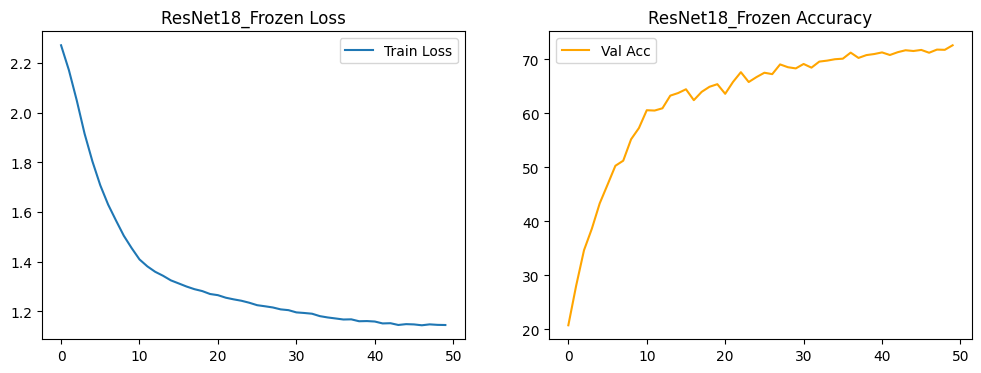

FINAL TEST ACCURACY: 74.28%


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_acc,▁
total_time,▁
train_loss,█▇▇▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇▇████████████████
epoch,50
test_acc,74.28
total_time,1622.51179
train_loss,1.14505
val_acc,72.58



 2: Unfrozen (Fine-Tuning + Label Smoothing)



 Starting : ResNet18_FineTune
 Building ResNet18 (Strategy: unfreeze)
   Epoch 1/50 | Loss: 2.300 | Val Acc: 14.60%
   Epoch 2/50 | Loss: 2.256 | Val Acc: 20.52%
   Epoch 3/50 | Loss: 2.178 | Val Acc: 28.36%
   Epoch 4/50 | Loss: 2.020 | Val Acc: 37.46%
   Epoch 5/50 | Loss: 1.801 | Val Acc: 46.64%
   Epoch 6/50 | Loss: 1.604 | Val Acc: 55.26%
   Epoch 7/50 | Loss: 1.430 | Val Acc: 61.22%
   Epoch 8/50 | Loss: 1.289 | Val Acc: 66.62%
   Epoch 9/50 | Loss: 1.175 | Val Acc: 71.88%
   Epoch 10/50 | Loss: 1.080 | Val Acc: 75.18%
   Epoch 11/50 | Loss: 1.009 | Val Acc: 78.72%
   Epoch 12/50 | Loss: 0.944 | Val Acc: 81.02%
   Epoch 13/50 | Loss: 0.892 | Val Acc: 82.66%
   Epoch 14/50 | Loss: 0.855 | Val Acc: 84.18%
   Epoch 15/50 | Loss: 0.822 | Val Acc: 85.28%
   Epoch 16/50 | Loss: 0.789 | Val Acc: 86.10%
   Epoch 17/50 | Loss: 0.766 | Val Acc: 87.00%
   Epoch 18/50 | Loss: 0.750 | Val Acc: 87.84%
   Epoch 19/50 | Loss: 0.728 | Val Acc: 88.62%
   Epoch 20/50 | Loss: 0.714 | Val Acc: 88.60

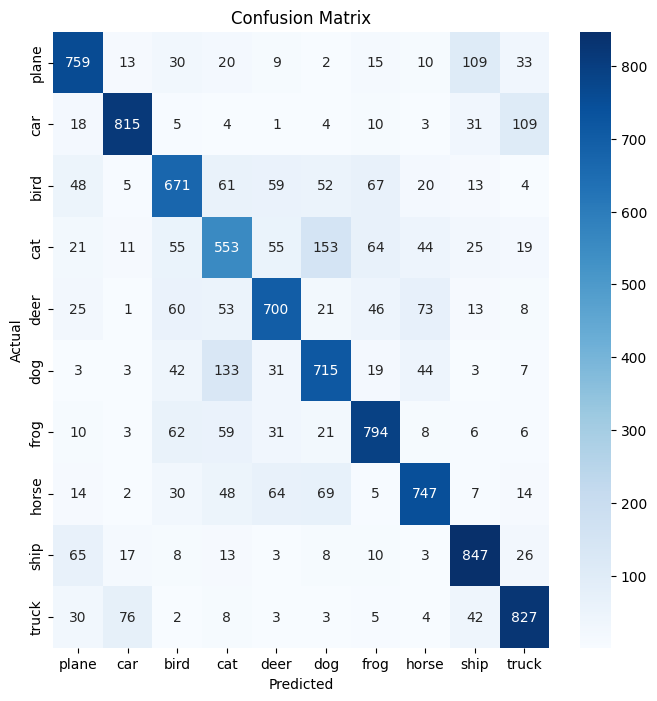

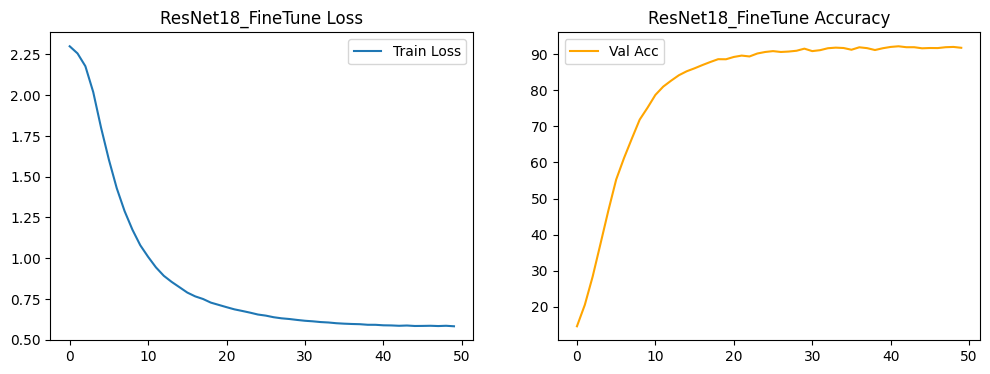

FINAL TEST ACCURACY: 92.35%


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_acc,▁
total_time,▁
train_loss,███▇▆▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▄▆▆▆▇▇▇▇████████████████████████████
epoch,50
test_acc,92.35
total_time,2156.11303
train_loss,0.5827
val_acc,91.78



 FINAL RESULTS
Frozen:    74.28%  (1623s)
Unfrozen:  92.35%  (2156s)


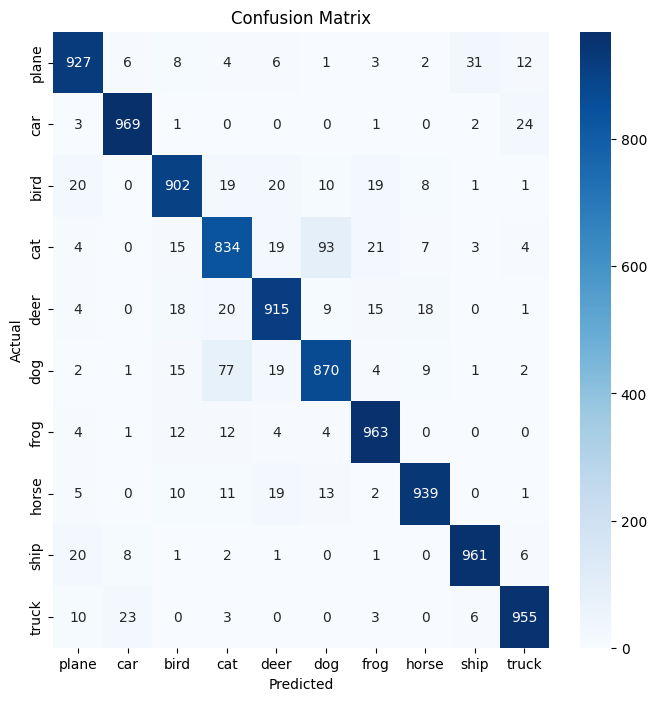

In [ ]:
# EXECUTION: FREEZE vs UNFREEZE


print(" 1: Frozen (Feature Extraction)")
# Note: Even 'frozen' works decent now because we patched Conv1!
acc_freeze, time_freeze = train_transfer("ResNet18_Frozen", strategy="freeze", epochs=50)

print("\n 2: Unfrozen (Fine-Tuning + Label Smoothing)")
# This should destroy the competition
acc_unfreeze, time_unfreeze = train_transfer("ResNet18_FineTune", strategy="unfreeze", epochs=50)

# Summary
print("\n FINAL RESULTS")
print(f"Frozen:    {acc_freeze:.2f}%  ({time_freeze:.0f}s)")
print(f"Unfrozen:  {acc_unfreeze:.2f}%  ({time_unfreeze:.0f}s)")

In [ ]:
# Checking the Test images

from PIL import Image
from google.colab import files # For uploading custom images
import os

# CONFIGURATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
STATS = ((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))

# Path to your best model
MODEL_PATH = "/content/drive/MyDrive/Week3_Vision/models/ResNet18_FineTune_best.pth"


In [ ]:
#  REBUILD MODEL ARCHITECTURE

def get_inference_model():
    # We must define the EXACT same architecture as training
    model = timm.create_model('resnet18', pretrained=False, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(device)

In [ ]:
# LOAD WEIGHTS

print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    print(" Error: Model file not found! Check the path.")
else:
    model = get_inference_model()
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded successfully!")

Loading model from: /content/drive/MyDrive/Week3_Vision/models/ResNet18_FineTune_best.pth
Model loaded successfully!


In [ ]:
#  VISUALIZATION HELPER

def imshow(tensor, title=None, ax=None):
    """Un-normalize and display image"""
    tensor = tensor.cpu().clone()
    # Un-normalize
    for t, m, s in zip(tensor, STATS[0], STATS[1]):
        t.mul_(s).add_(m)

    img = tensor.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    if ax:
        ax.imshow(img)
        if title: ax.set_title(title, fontsize=10)
        ax.axis('off')
    else:
        plt.imshow(img)
        plt.show()


 Checking a batch from the CIFAR-10 Test Set...


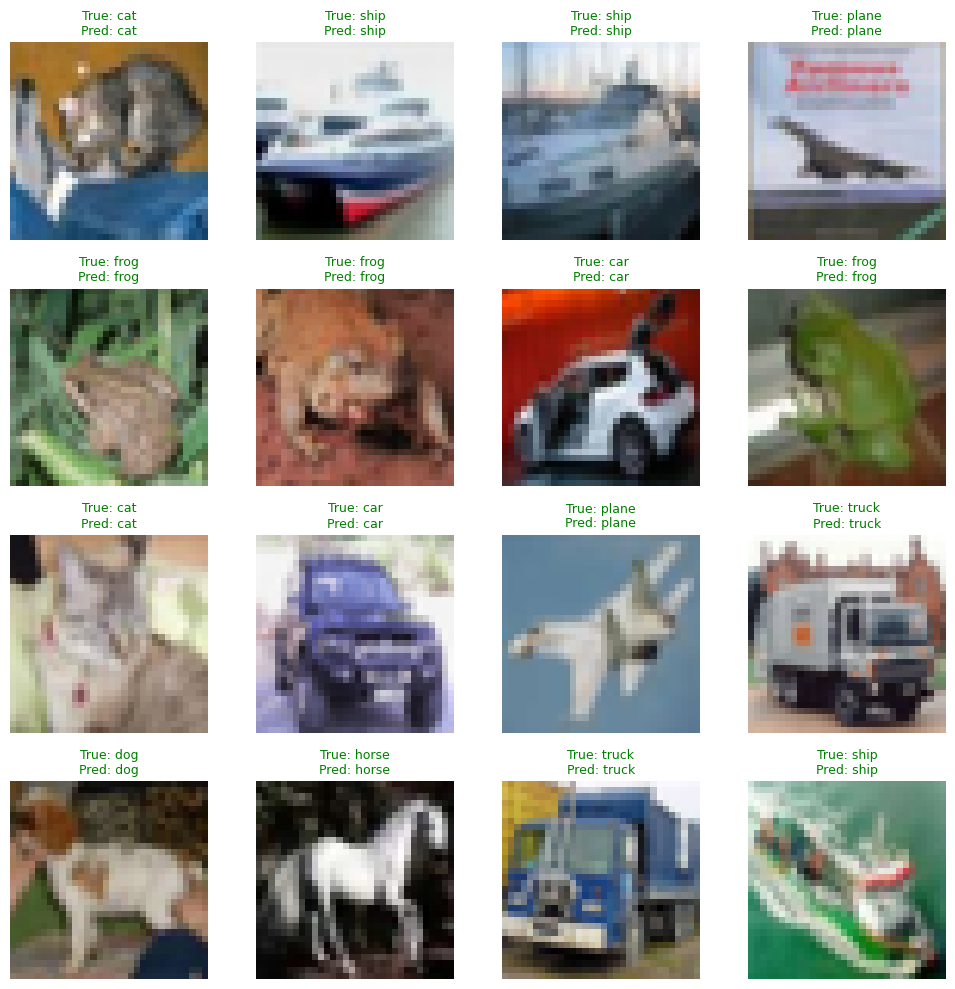

In [ ]:
# PART A: CHECK TEST SET PREDICTIONS

print("\n Checking a batch from the CIFAR-10 Test Set...")

# Get a batch
_, _, test_loader = get_dataloaders(batch_size=16) # Reuse your loader function
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Predict
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Plot 4x4 Grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i in range(16):
    img = images[i]
    true_label = CLASSES[labels[i]]
    pred_label = CLASSES[preds[i]]

    # Color: Green if correct, Red if wrong
    color = "green" if true_label == pred_label else "red"
    title = f"True: {true_label}\nPred: {pred_label}"

    # Display
    img_cpu = img.cpu().clone()
    for t, m, s in zip(img_cpu, STATS[0], STATS[1]):
        t.mul_(s).add_(m)
    np_img = img_cpu.permute(1, 2, 0).numpy()
    np_img = np.clip(np_img, 0, 1)

    axes[i].imshow(np_img)
    axes[i].set_title(title, color=color, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Upload a picture of a Dog, Plane, Car, etc.


Saving plane.jpg to plane.jpg


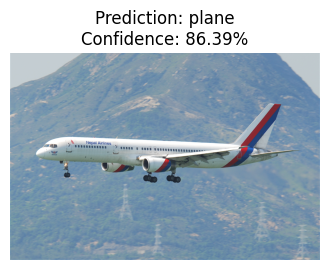

In [ ]:
# PART B: TEST YOUR OWN IMAGE

print("Upload a picture of a Dog, Plane, Car, etc.")
uploaded = files.upload()

# Transform for custom images
custom_transform = transforms.Compose([
    transforms.Resize((32, 32)), # Must resize to match model input
    transforms.ToTensor(),
    transforms.Normalize(*STATS)
])

for fn in uploaded.keys():
    # Load and Preprocess
    path = fn
    img_pil = Image.open(path).convert('RGB')
    img_tensor = custom_transform(img_pil).unsqueeze(0).to(device) # Add batch dim

    # Predict
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    pred_class = CLASSES[pred_idx.item()]
    confidence = conf.item() * 100

    # Show Result
    plt.figure(figsize=(4,4))
    plt.imshow(img_pil)
    plt.title(f"Prediction: {pred_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

In [ ]:
# 1. Install specific tools for Day 4
!pip install grad-cam torchmetrics --quit


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --quit


In [4]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision
from torch.utils.data import DataLoader
import timm
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 2. Setup Device & Drive
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drive.mount('/content/drive')
print(f"Using Device: {device}")


Mounted at /content/drive
Using Device: cuda


In [8]:
# 3. Define the Model Architecture (EXACTLY as Day 3)
def get_model():
    model = timm.create_model('resnet18', pretrained=False, num_classes=10)
    # Re-apply the CIFAR Patch so weights load correctly
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(device)



In [9]:
# 4. Load the Best Model
MODEL_PATH = "/content/drive/MyDrive/Week3_Vision/models/ResNet18_FineTune_best.pth"
model = get_model()

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print(" Model Weights Loaded Successfully!")
else:
    raise FileNotFoundError(f" Model not found at {MODEL_PATH}. Didnt run day-3")


 Model Weights Loaded Successfully!


In [11]:
# 5. Prepare Test Data
STATS = ((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*STATS)
])
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
CLASSES = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s]


In [12]:
# Misclassification Review
def get_misclassified(model, loader, num_images=20):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Find indices where prediction != target
            idxs_mask = ((preds == targets) == False).nonzero()

            for i in idxs_mask:
                idx = i.item()
                # Save input, pred, target
                misclassified.append({
                    'img': inputs[idx].cpu(),
                    'pred': preds[idx].item(),
                    'true': targets[idx].item()
                })
                if len(misclassified) >= num_images:
                    return misclassified
    return misclassified




In [13]:
# 1. Get Data
bad_samples = get_misclassified(model, test_loader, num_images=20)


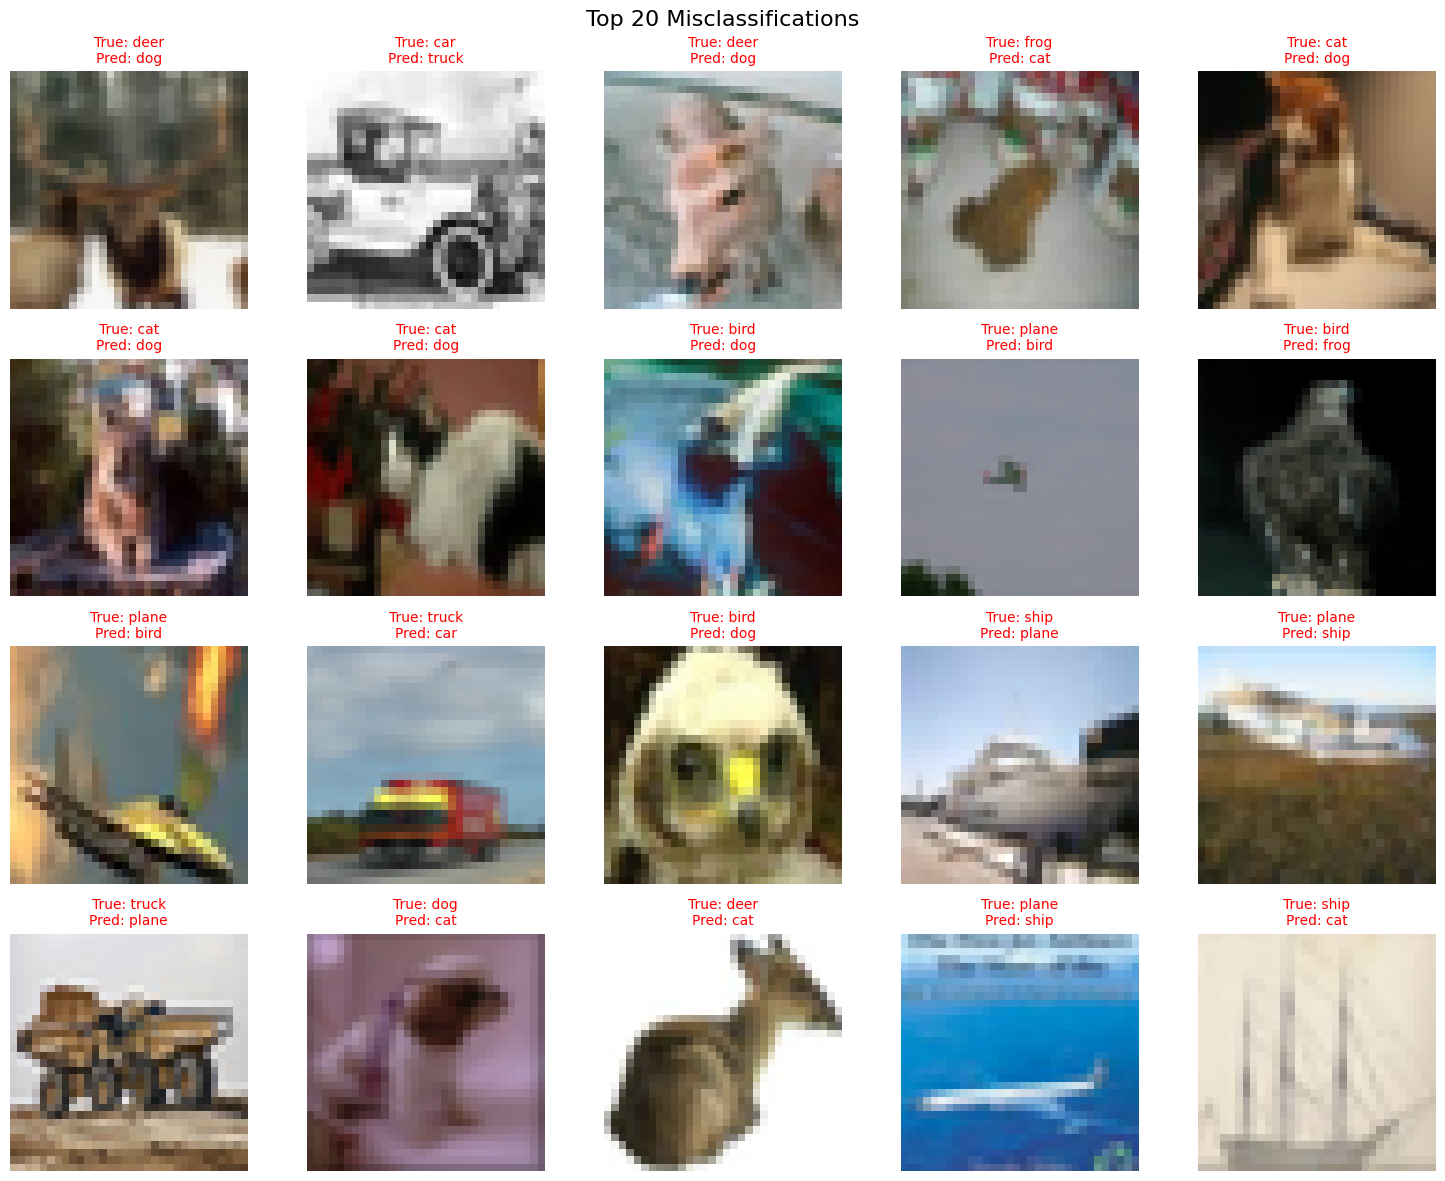

In [14]:
# 2. Plot
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, item in enumerate(bad_samples):
    img = item['img']
    # Un-normalize for display
    for t, m, s in zip(img, STATS[0], STATS[1]):
        t.mul_(s).add_(m)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    # Red title = Wrong
    true_name = CLASSES[item['true']]
    pred_name = CLASSES[item['pred']]

    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_name}\nPred: {pred_name}", color='red', fontsize=10)
    axes[i].axis('off')

plt.suptitle("Top 20 Misclassifications", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Grad CAM

In [15]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 89.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=3124d64a897efb3bac529acbe49a4707862dc3164d4f2ae48d4b194f9bb701c8
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.utils import make_grid

# 1. Define Target Layer
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)


Saving individual GradCAM images to: /content/drive/MyDrive/Week3_Vision/gradcam_images
Gallery overview saved to: /content/drive/MyDrive/Week3_Vision/gradcam_images/gradcam_gallery.png


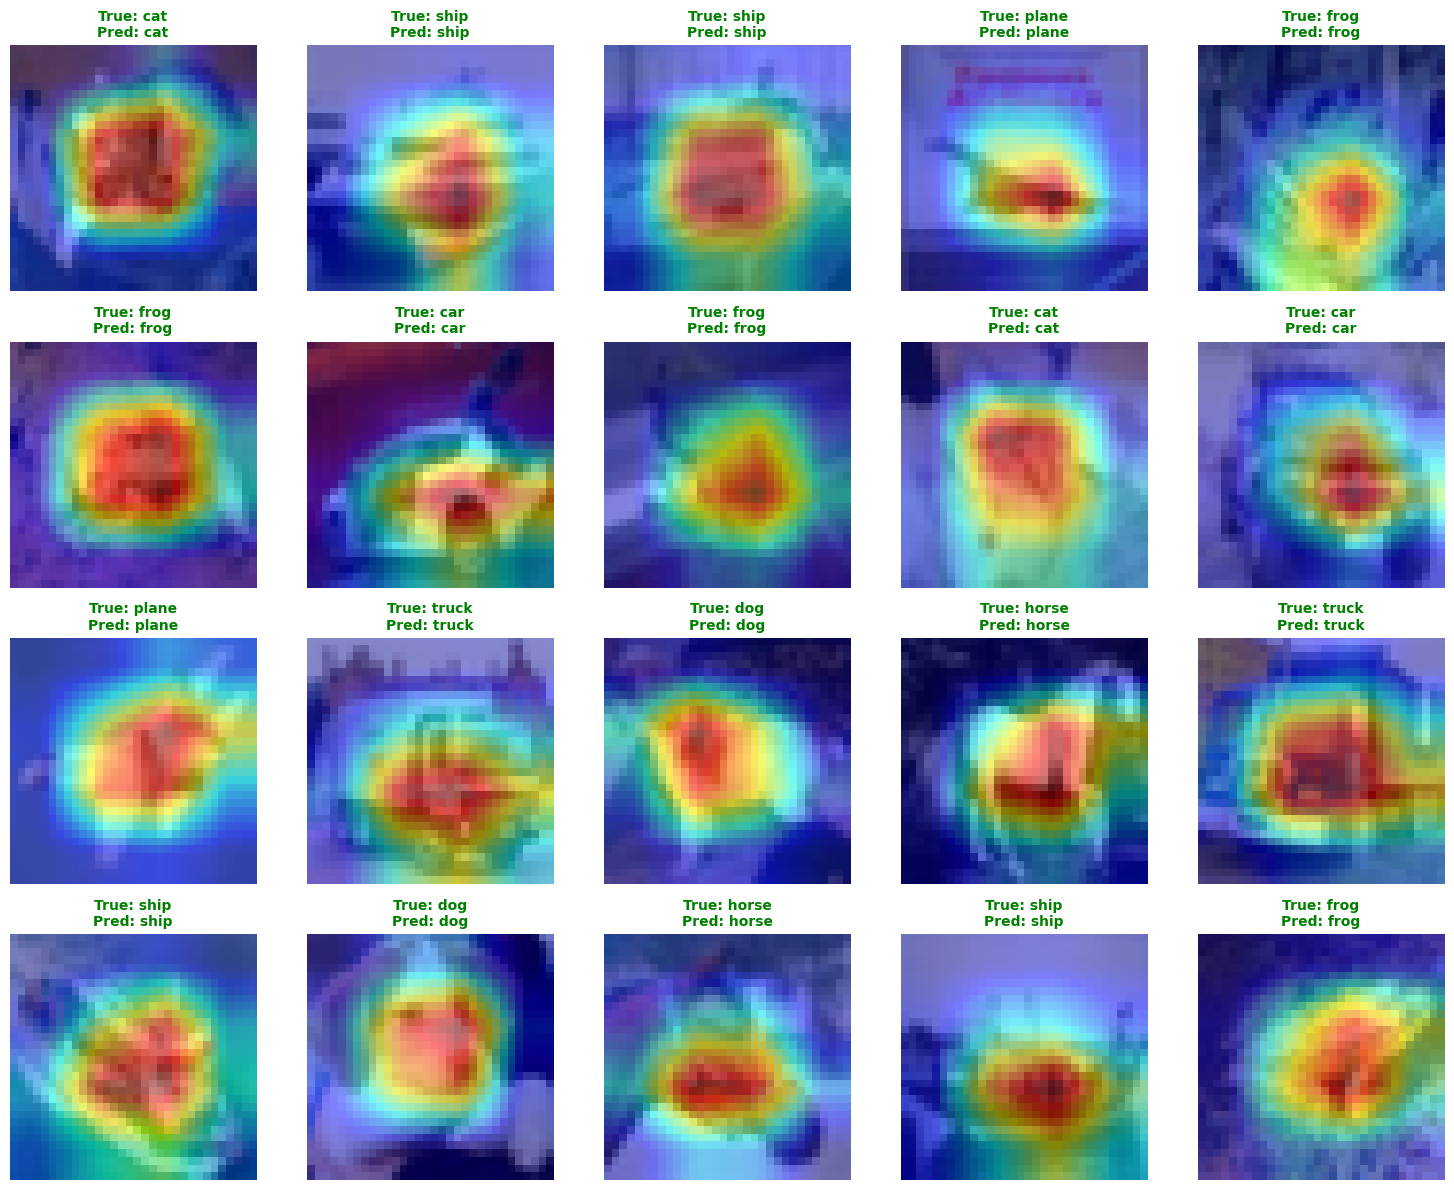

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.utils import make_grid
import os # Import os module for directory operations

# 1. Define Target Layer
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Define the directory to save individual GradCAM images
GRADCAM_SAVE_DIR = "/content/drive/MyDrive/Week3_Vision/gradcam_images"

def generate_gallery(model, loader, num_img=20):
    model.eval()
    dataiter = iter(loader)
    images, labels = next(dataiter)

    # Select first 'num_img' images
    images = images[:num_img]
    labels = labels[:num_img]

    # 2. Get Predictions
    inputs = images.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

    # 3. Generate Heatmaps
    grayscale_cam = cam(input_tensor=inputs, targets=None)

    # Ensure the saving directory exists
    os.makedirs(GRADCAM_SAVE_DIR, exist_ok=True)
    print(f"Saving individual GradCAM images to: {GRADCAM_SAVE_DIR}")

    # 4. Create the Visualization Grid for display (optional, but good for overview)
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()

    for i in range(num_img):
        # Un-normalize image for display
        img = images[i].cpu()
        for t, m, s in zip(img, STATS[0], STATS[1]):
            t.mul_(s).add_(m)
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        # Overlay Heatmap
        visualization = show_cam_on_image(img, grayscale_cam[i, :], use_rgb=True)

        # Labels
        pred_cls = CLASSES[preds[i].item()]
        true_cls = CLASSES[labels[i].item()]
        color = 'green' if pred_cls == true_cls else 'red'

        # Save individual image to Drive
        individual_save_path = os.path.join(GRADCAM_SAVE_DIR, f"gradcam_{i+1}_true_{true_cls}_pred_{pred_cls}.png")
        plt.imsave(individual_save_path, visualization)

        # Display on the grid
        axes[i].imshow(visualization)
        axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=10, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    # Save the entire Gallery for overview (if desired)
    gallery_save_path = os.path.join(GRADCAM_SAVE_DIR, "gradcam_gallery.png")
    plt.savefig(gallery_save_path, dpi=150)
    print(f"Gallery overview saved to: {gallery_save_path}")
    plt.show()

# Run it
generate_gallery(model, test_loader, num_img=20)

 Robustness Check (Noise Level: 0.1) 
Clean Accuracy: 92.35%
Noisy Accuracy: 88.20%
Drop: 4.15%


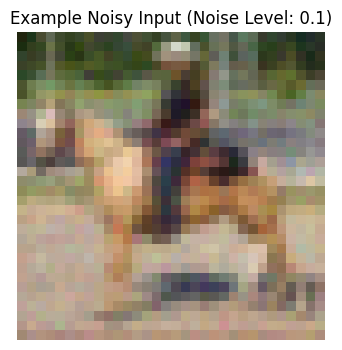

accuracy_drop,▁
clean_accuracy,▁
noise_level,▁
noisy_accuracy,▁
accuracy_drop,4.15
clean_accuracy,92.35
noise_level,0.1
noisy_accuracy,88.2


In [30]:
# ADVERSERIAL NOISE
def test_robustness(model, loader, noise_level=0.1):
    # Initialize WandB for this specific logging task
    wandb.init(project="Week-3", name=f"Adversarial_Robustness_Test_NL{noise_level}", reinit=True)

    model.eval()
    correct_clean = 0
    correct_noisy = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # 1. Clean Prediction
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct_clean += preds.eq(targets).sum().item()

            # 2. Add Noise (Adversarial Sanity Check)
            noise = torch.randn_like(inputs) * noise_level
            noisy_inputs = inputs + noise

            # 3. Noisy Prediction
            outputs_noisy = model(noisy_inputs)
            _, preds_noisy = torch.max(outputs_noisy, 1)
            correct_noisy += preds_noisy.eq(targets).sum().item()

            total += targets.size(0)

    acc_clean = 100 * correct_clean / total
    acc_noisy = 100 * correct_noisy / total
    accuracy_drop = acc_clean - acc_noisy

    print(f" Robustness Check (Noise Level: {noise_level}) ")
    print(f"Clean Accuracy: {acc_clean:.2f}%")
    print(f"Noisy Accuracy: {acc_noisy:.2f}%")
    print(f"Drop: {accuracy_drop:.2f}%")

    # Log metrics to WandB
    wandb.log({
        "noise_level": noise_level,
        "clean_accuracy": acc_clean,
        "noisy_accuracy": acc_noisy,
        "accuracy_drop": accuracy_drop
    })

    # Show one noisy example and log it to WandB
    fig = plt.figure(figsize=(4,4))
    noisy_img = (inputs[0] + noise[0]).cpu()
    # Un-normalize
    for t, m, s in zip(noisy_img, STATS[0], STATS[1]):
        t.mul_(s).add_(m)
    plt.imshow(np.clip(noisy_img.permute(1, 2, 0).numpy(), 0, 1))
    plt.title(f"Example Noisy Input (Noise Level: {noise_level})")
    plt.axis('off')
    plt.show()

    wandb.log({"example_noisy_image": wandb.Image(fig)})
    plt.close(fig) # Close the figure to prevent it from being displayed twice if you run the cell again

    # Finish the WandB run
    wandb.finish()

test_robustness(model, test_loader, noise_level=0.1)

In [19]:
# Calibration (ECE & Reliability)

In [22]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



--- Calibration Stats ---
Expected Calibration Error (ECE): 0.0755
(Lower is better. < 0.05 is excellent, > 0.15 is uncalibrated)


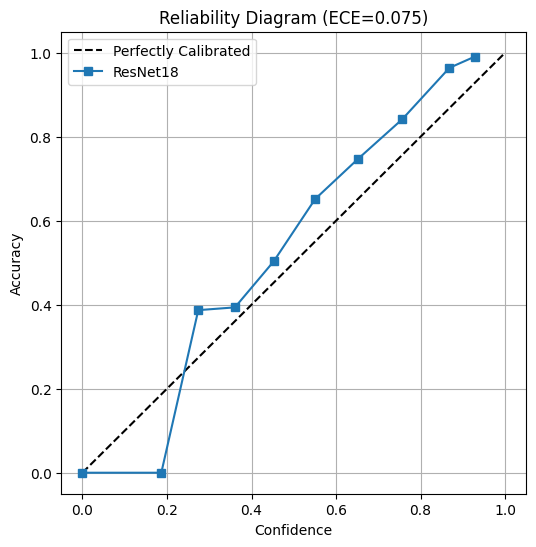

ece_score,▁
ece_score,0.07548


In [29]:
from torchmetrics.classification import CalibrationError
import wandb # Import wandb

def check_calibration(model, loader):
    # Initialize WandB for this specific logging task
    wandb.init(project="Week-3", name="Model_Calibration_Analysis", reinit=True)

    model.eval()
    all_probs = []
    all_targets = []

    # 1. Collect Probabilities
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu())
            all_targets.append(targets.cpu())

    all_probs = torch.cat(all_probs)
    all_targets = torch.cat(all_targets)

    # 2. Compute ECE
    ece_metric = CalibrationError(task="multiclass", num_classes=10, norm='l1')
    ece_score = ece_metric(all_probs, all_targets)

    print(f"\n--- Calibration Stats ---")
    print(f"Expected Calibration Error (ECE): {ece_score.item():.4f}")
    print("(Lower is better. < 0.05 is excellent, > 0.15 is uncalibrated)")

    # Log ECE to WandB
    wandb.log({"ece_score": ece_score.item()})

    # 3. Plot Reliability Diagram
    # This plots 'Confidence' vs 'Accuracy'
    # Perfect calibration is the diagonal line y=x

    # Simple binning logic for plotting
    confidences, predictions = torch.max(all_probs, 1)
    accuracies = predictions.eq(all_targets)

    bins = torch.linspace(0, 1, 11)
    bin_accs = []
    bin_confs = []

    for i in range(len(bins)-1):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if mask.sum() > 0:
            bin_accs.append(accuracies[mask].float().mean().item())
            bin_confs.append(confidences[mask].mean().item())
        else:
            bin_accs.append(0)
            bin_confs.append(0)

    fig = plt.figure(figsize=(6, 6)) # Store figure in a variable
    plt.plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
    plt.plot(bin_confs, bin_accs, 's-', label="ResNet18")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram (ECE={ece_score.item():.3f})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Log the plot to WandB
    wandb.log({"reliability_diagram": wandb.Image(fig)})

    # Finish the WandB run
    wandb.finish()

check_calibration(model, test_loader)

In [31]:
def plot_robustness_curve(model, loader):
    print("Running Noise Stress Test")
    noise_levels = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
    accuracies = []

    model.eval()

    for noise_amt in noise_levels:
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in loader:
                inputs, targets = inputs.to(device), targets.to(device)

                # Add Noise (Fixed Seed for consistency within this loop)
                # We re-seed per batch to ensure consistent noise generation logic
                torch.manual_seed(42)
                noise = torch.randn_like(inputs) * noise_amt
                noisy_inputs = inputs + noise

                outputs = model(noisy_inputs)
                _, preds = torch.max(outputs, 1)
                correct += preds.eq(targets).sum().item()
                total += targets.size(0)

        acc = 100 * correct / total
        accuracies.append(acc)
        print(f"   Noise {noise_amt:.2f}: {acc:.2f}%")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(noise_levels, accuracies, marker='o', linewidth=2, color='red')
    plt.title("Model Robustness: Accuracy vs Noise Level")
    plt.xlabel("Noise Level (Intensity)")
    plt.ylabel("Test Accuracy (%)")
    plt.grid(True)
    plt.ylim(0, 100)

    # Save for report
    plt.savefig("robustness_curve.png")
    plt.show()

Running Noise Stress Test
   Noise 0.00: 92.35%
   Noise 0.05: 91.61%
   Noise 0.10: 88.15%
   Noise 0.15: 81.05%
   Noise 0.20: 72.65%
   Noise 0.25: 63.44%
   Noise 0.30: 54.13%


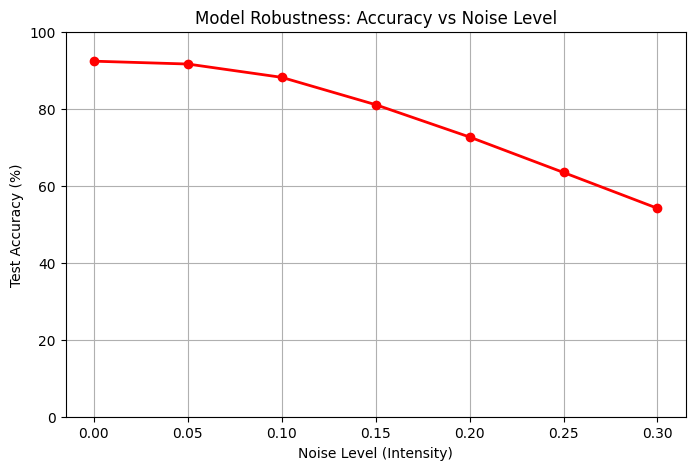

In [32]:
plot_robustness_curve(model, test_loader)

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

def find_optimal_temperature(model, loader):
    print("Optimizing Temperature for Calibration...")
    model.eval()

    # 1. Collect all raw logits (before Softmax) and labels
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for input, label in loader:
            input = input.to(device)
            logits = model(input)
            logits_list.append(logits)
            labels_list.append(label)

    logits = torch.cat(logits_list).to(device)
    labels = torch.cat(labels_list).to(device)

    # 2. Temperature Parameter (Single Scalar)
    # Initialize at 1.5 (assuming model is slightly overconfident)
    temperature = nn.Parameter(torch.ones(1).to(device) * 1.5)

    # 3. Optimize NLL (Negative Log Likelihood)
    optimizer = optim.LBFGS([temperature], lr=0.01, max_iter=50)
    criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        # Scale logits by temperature
        loss = criterion(logits / temperature, labels)
        loss.backward()
        return loss

    optimizer.step(closure)

    # 4. Result
    best_t = temperature.item()
    print(f" Optimal Temperature found: T = {best_t:.4f}")
    # print("Using this value in your inference.py")
    return best_t

In [34]:
# Run on Test Loader (or Val Loader ideally)
BEST_TEMP = find_optimal_temperature(model, test_loader)

Optimizing Temperature for Calibration...
 Optimal Temperature found: T = 0.9817
